# 01 — Dataset overview

**Question this notebook answers:** What is in `project-resources/Fotos/`, and what can we trust about it?

Specifically:
- How many photos, in what formats, from what sources?
- Do we have the metadata the APG brief assumes (GPS, EXIF timestamps)?
- What does the numeric filename prefix (1, 2, 3, …) mean?
- Resolution, file size, time range — what is feasible for inference at scale?

Why it matters: the brief promises "geo-referenced construction site photos." Our sample is mostly WhatsApp downloads, which strips EXIF. That single fact changes the pipeline architecture and is worth confirming before writing any QC logic.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from src.cache import load_or_build_photo_index

sns.set_theme(style="whitegrid", context="notebook")
df = load_or_build_photo_index()
df["aspect"] = df["width"] / df["height"]
df["orientation"] = np.where(df["aspect"] >= 1, "landscape", "portrait")
print(f"{len(df):,} photos indexed")
df.head(3)

3,929 photos indexed


,path,filename,prefix,source_kind,filesize,width,height,exif_datetime,filename_date,has_exif,has_gps,gps_lat,gps_lon,gps_alt,camera_make,camera_model,error,best_datetime,aspect,orientation
0,/Users/rezafuru/repos/personal/OepenTrench/pro...,1_IMG-20240731-WA0029.jpg,1,whatsapp_img,2262846,3000,4000,NaT,2024-07-31,False,False,NaN,NaN,NaN,None,None,None,2024-07-31,0.75,portrait
1,/Users/rezafuru/repos/personal/OepenTrench/pro...,1_IMG-20240731-WA0030.jpg,1,whatsapp_img,2063657,3000,4000,NaT,2024-07-31,False,False,NaN,NaN,NaN,None,None,None,2024-07-31,0.75,portrait
2,/Users/rezafuru/repos/personal/OepenTrench/pro...,1_IMG-20240809-WA0025.jpg,1,whatsapp_img,400743,1080,1440,NaT,2024-08-09,False,False,NaN,NaN,NaN,None,None,None,2024-08-09,0.75,portrait


## 1 · Headline counts

In [2]:
n = len(df)
print(f"Total photos:                 {n:,}")
print(f"With ANY EXIF block:          {int(df.has_exif.sum()):,}  ({df.has_exif.mean():.1%})")
print(f"With GPS coordinates:         {int(df.has_gps.sum()):,}  ({df.has_gps.mean():.1%})")
print(f"With camera make/model:       {int(df.camera_make.notna().sum()):,}")
print(f"With EXIF DateTimeOriginal:   {int(df.exif_datetime.notna().sum()):,}")
print(f"Total disk size:              {df.filesize.sum()/1e9:.2f} GB")
print(f"Read errors:                  {int(df.error.notna().sum())}")

Total photos:                 3,929
With ANY EXIF block:          17  (0.4%)
With GPS coordinates:         5  (0.1%)
With camera make/model:       5
With EXIF DateTimeOriginal:   5
Total disk size:              2.02 GB
Read errors:                  0


**Headline finding — the dataset is mostly stripped of EXIF.** WhatsApp removes camera metadata on upload, so the per-photo GPS and timestamp guarantees the brief implies cannot be assumed on real submissions.

Implication for the pipeline: geo-matching to trench segments cannot rely on per-image GPS. We need a fallback path — lot grouping from filename / folder, plus user-supplied lot↔project mapping at upload time.

## 2 · Source kind (where did each photo come from?)

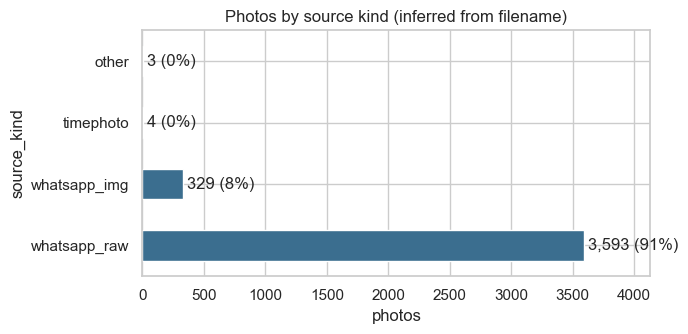

source_kind
whatsapp_raw    3593
whatsapp_img     329
timephoto          4
other              3
Name: count, dtype: int64

In [3]:
src_counts = df.source_kind.value_counts()
fig, ax = plt.subplots(figsize=(7, 3.5))
src_counts.plot(kind="barh", ax=ax, color="#3b6e8f")
ax.set_xlabel("photos"); ax.set_title("Photos by source kind (inferred from filename)")
for i, v in enumerate(src_counts.values):
    ax.text(v + 30, i, f"{v:,} ({v/len(df):.0%})", va="center")
ax.set_xlim(0, src_counts.max() * 1.15)
plt.tight_layout(); plt.show()
src_counts

- `whatsapp_raw`: filenames like `WhatsApp Image 2024-08-26 at 18_18_36.jpeg` — saved manually from chat. **Date in filename, no EXIF.**
- `whatsapp_img`: filenames like `IMG-20240731-WA0029.jpg` — auto-saved by WhatsApp on Android. Date in filename, no EXIF.
- `timephoto` / `other`: a handful of camera-app captures, some preserve EXIF.

Lesson: filename is the *most reliable* timestamp source we have. EXIF is the exception, not the rule.

## 3 · Filename prefix — what does the leading number mean?

In [4]:
prefix = df.prefix.fillna("(none)")
counts = prefix.value_counts().sort_index()
print(counts)
print()
print(f"Photos WITH a prefix:    {int(df.prefix.notna().sum()):,}  ({df.prefix.notna().mean():.1%})")
print(f"Photos WITHOUT a prefix: {int(df.prefix.isna().sum()):,}  ({df.prefix.isna().mean():.1%})")

prefix
(none)    2902
1          471
2          471
3           68
4           13
5            2
6            1
7            1
Name: count, dtype: int64

Photos WITH a prefix:    1,027  (26.1%)
Photos WITHOUT a prefix: 2,902  (73.9%)


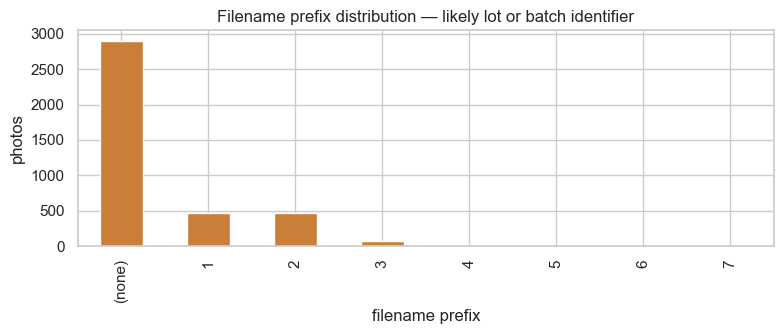

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
counts.plot(kind="bar", ax=ax, color="#c97f3a")
ax.set_xlabel("filename prefix"); ax.set_ylabel("photos")
ax.set_title("Filename prefix distribution — likely lot or batch identifier")
plt.tight_layout(); plt.show()

**Interpretation:** prefixes are present on ~26% of files, range 1–7, heavily skewed (1 and 2 each have ~470; 3 has ~70; the rest are negligible). Most photos (74%) have no prefix at all.

Working hypothesis: the prefix is a **lot identifier** added during a hand-curation step — only some lots were tagged. Without ground truth we can't confirm. **Need to ask the challenge owner** what the prefix actually represents and whether unprefixed photos belong to a default lot.

This matters because Criterion 5 (duplicates *across lots*) needs a reliable lot label. Filename alone is not enough.

## 4 · Time coverage (best-effort timestamp per photo)

In [6]:
ts = df["best_datetime"].dropna()
print(f"Photos with a usable date: {len(ts):,} / {len(df):,}  ({len(ts)/len(df):.1%})")
print(f"Date range: {ts.min().date()} → {ts.max().date()}")
print(f"Span: {(ts.max() - ts.min()).days} days")

Photos with a usable date: 3,523 / 3,929  (89.7%)
Date range: 2024-07-22 → 2025-11-12
Span: 478 days


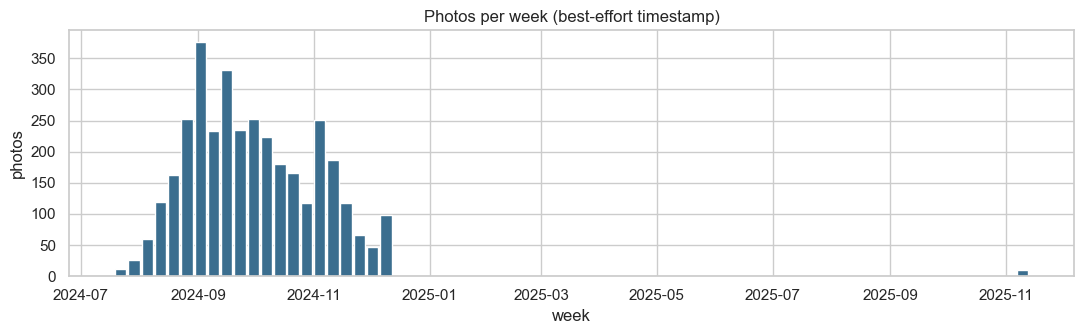

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.5))
weekly = ts.dt.to_period("W").dt.to_timestamp().value_counts().sort_index()
ax.bar(weekly.index, weekly.values, width=6, color="#3b6e8f")
ax.set_title("Photos per week (best-effort timestamp)")
ax.set_xlabel("week"); ax.set_ylabel("photos")
plt.tight_layout(); plt.show()

Construction cadence is visible — quiet weeks vs. spikes likely correspond to specific lot openings.

## 5 · Resolution and orientation

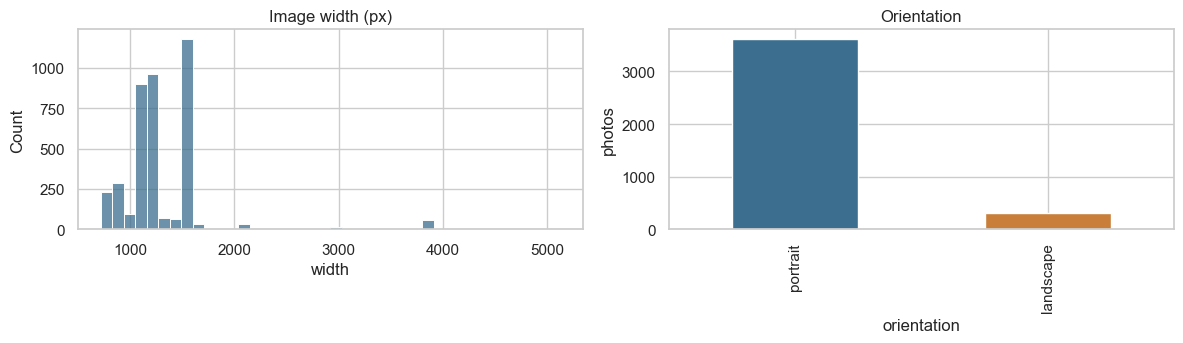

,width,height,filesize
count,3929.0,3929.0,3929.0
mean,1282.0,1758.0,515168.0
std,435.0,558.0,354100.0
min,720.0,720.0,58436.0
10%,899.0,1280.0,245176.0
50%,1200.0,1600.0,431011.0
90%,1536.0,2048.0,794369.0
max,5120.0,5120.0,7703903.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
sns.histplot(df.width, bins=40, ax=axes[0], color="#3b6e8f")
axes[0].set_title("Image width (px)"); axes[0].set_xlabel("width")
df.orientation.value_counts().plot(kind="bar", ax=axes[1], color=["#3b6e8f", "#c97f3a"])
axes[1].set_title("Orientation"); axes[1].set_ylabel("photos")
plt.tight_layout(); plt.show()
df[["width", "height", "filesize"]].describe(percentiles=[.1, .5, .9]).round(0)

Median photo is ~1.2 MP and portrait — phone snapshots, not professional documentation rigs. Plenty for vision models but expect noise: motion blur, hands in frame, mixed lighting, occluded ruler.

## 6 · Spot-check: 24 random photos by source kind

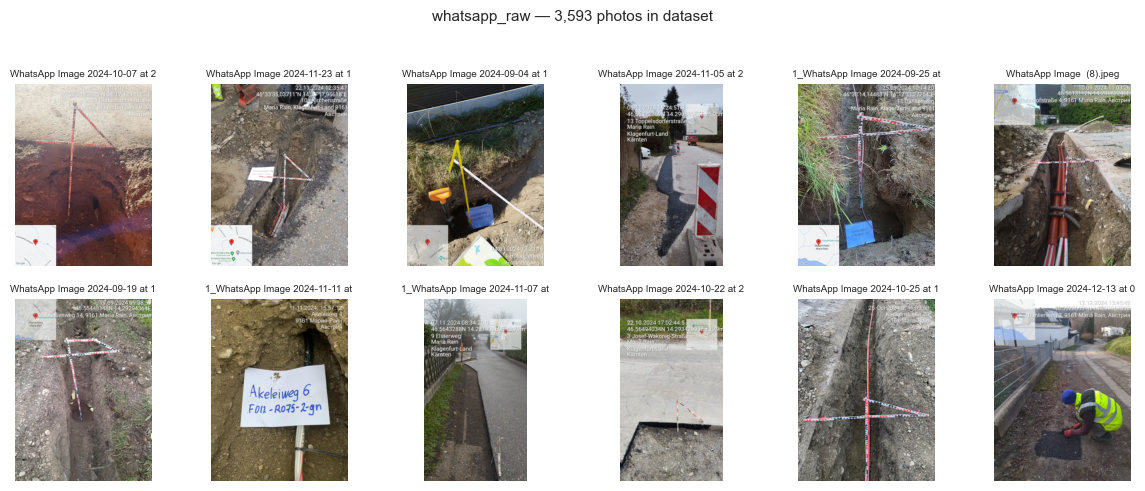

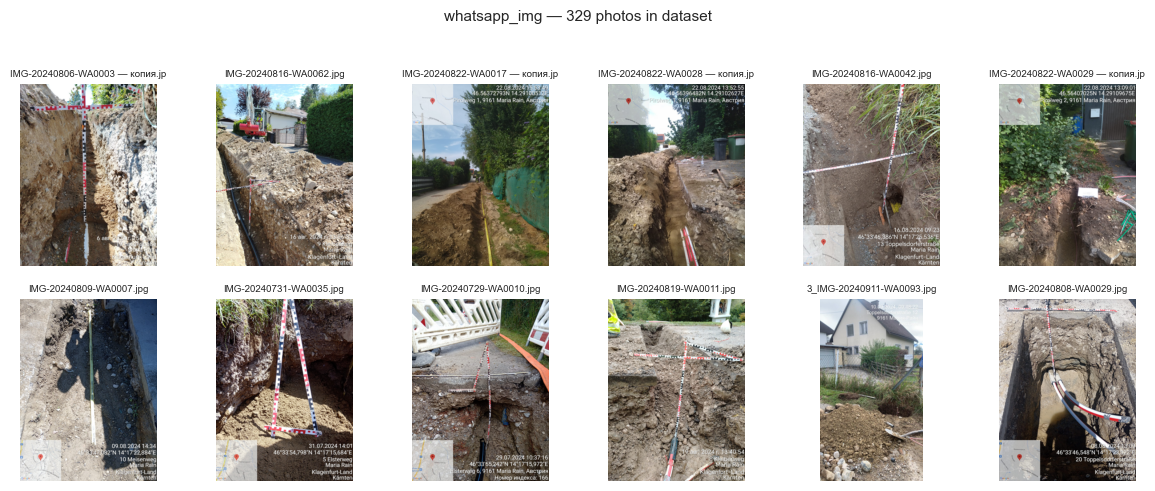

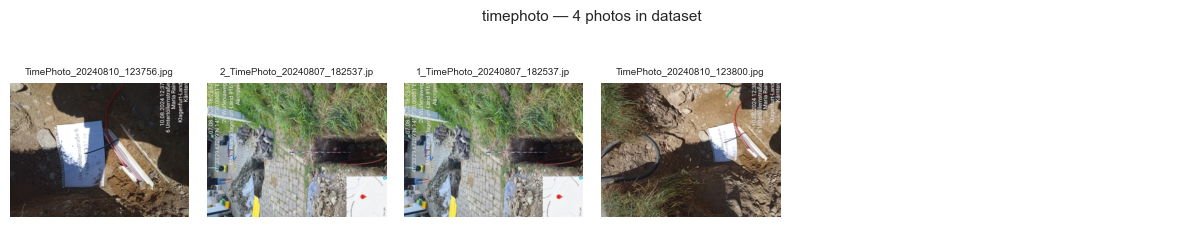

In [9]:
import random
random.seed(7)
def show_grid(paths, title, ncols=6, scale=2.0):
    nrows = (len(paths) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*scale, nrows*scale*1.2))
    axes = np.atleast_2d(axes)
    for ax in axes.ravel(): ax.axis("off")
    for ax, p in zip(axes.ravel(), paths):
        try:
            im = Image.open(p); im.thumbnail((320, 320)); ax.imshow(im)
            ax.set_title(Path(p).name[:30], fontsize=7)
        except Exception as e:
            ax.set_title(f"ERR {e}", fontsize=7)
    fig.suptitle(title, fontsize=11, y=1.02)
    plt.tight_layout(); plt.show()

for src in ["whatsapp_raw", "whatsapp_img", "timephoto"]:
    sub = df[df.source_kind == src]
    if len(sub) == 0: continue
    paths = sub.path.sample(min(12, len(sub)), random_state=7).tolist()
    show_grid(paths, f"{src} — {len(sub):,} photos in dataset")

**What we actually see in the photos** (visual scan):
- Open trenches with visible duct bundles, sand bedding, warning tape (the QC-positive cases)
- Backfilled / finished trenches, asphalt patches
- Reference photos with rulers, tape measures, marked depths
- Wide shots of the road / scene with no trench visible
- Closed manholes, splice cabinets, building facades
- Some photos are blurry, very dark, or have a hand / boot in frame

This visual variance is the actual modelling problem: a single classifier per criterion is unlikely to work; we need **per-criterion detectors** or a **VLM with structured prompts**.

## Takeaways for the pipeline

1. **Don't trust EXIF GPS.** Build the geo-matching path around **upload-time metadata** (project + lot + optional GPS), with EXIF as a bonus confidence boost when present.
2. **Lot grouping is the right unit of evaluation** — not individual photos. Brief explicitly asks for project- and lot-level deficiency reports.
3. **Per-criterion detectors** instead of one classifier — warning tape, sand bedding, depth reference, side view are visually distinct and benefit from specialised checks.
4. **Recall-first thresholds.** The cost of a missed defect (€42M+ network exposure mentioned in the brief) dwarfs the cost of human re-review of a false positive.
5. **Duplicate detection needs perceptual hashing**, not just file hashing — WhatsApp re-encoding changes bytes but preserves the visual content. See `03_examples_and_duplicates.ipynb`.